### Libraries

In [210]:
import pandas as pd
import numpy as np
import nibabel as nb
import seaborn as sns
import os
import glob
import scipy.stats
from brainspace.mesh.mesh_io import read_surface
from brainspace.plotting import plot_hemispheres
from brainspace.gradient import GradientMaps
from brainspace.mesh.array_operations import smooth_array
from brainstat.stats.SLM import SLM
from brainstat.stats.terms import FixedEffect
from brainstat.datasets.base import combine_surfaces
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import pairwise_distances

### Variables

In [211]:
# Path to MICAPIPE
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')
mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k_int = np.concatenate((mask_lh, mask_rh), axis=0)


# Labels and boolean mask
mask_5k = mask_5k_int != 0

# load stuff
from brainspace.datasets import load_mask
mask_32k = load_mask(join=True)

# Load canonical inflated fsLR-32k surface
inf32_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.inflated.surf.gii', itype='gii')
inf32_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.inflated.surf.gii', itype='gii')

# Set dataset PNI as working directory
os.chdir('/data_/mica3')

# full path to 
database = 'BIDS_PNI'

# List of subjects
subject = 'PNC019'
ses = 'ses-03'

# For MIC subjects
subject_dir = glob.glob(f'{database}/derivatives/micapipe_v0.2.0/sub-{subject}')[0]

## Load intensity profiles

In [80]:
# BigBrain
BBgm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/BB_GM_IPs_5k.npy')
BBswm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/BB_SWM_IPs_5k.npy')
BB_int_profile = np.vstack((BBgm_int, BBswm_int))

# AHEAD - Bielschowsky
ABgm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/AHEAD_gm_Bieloschowsky.npy')
ABfswm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/AHEAD_Bieloschowsky_FS.npy')
AB_int_profile = np.vstack((ABgm_int, ABfswm_int))

# AHEAD - Parvalbumin
APgm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/AHEAD_gm_Parvalbumin.npy')
APfswm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/AHEAD_Parvalbumin_FS.npy')
AP_int_profile = np.vstack((APgm_int, APfswm_int))

# T1map
T1map_gm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/PNC-10sub_T1map_gmIP.npy')
T1map_swm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/PNC-10sub_T1map_swmIP.npy')
T1map_int_profile = np.vstack((T1map_gm_int, np.flip(T1map_swm_int, axis=0)))

# MTSAT
MTSAT_gm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/PNC-10sub_MTsat_gmIP.npy')
MTSAT_swm_int = np.load('/host/verges/tank/data/youngeun/myjupyter/array/PNC-10sub_MTsat_swmIP.npy')
MTSAT_int_profile = np.vstack((MTSAT_gm_int, np.flip(MTSAT_swm_int, axis=0)))

In [212]:
# Combine each modalities
Hist_int_profile = np.stack((BB_int_profile, AB_int_profile, AP_int_profile), axis=2)
print(Hist_int_profile.shape)
Qmri_int_profile = np.stack((T1map_int_profile, MTSAT_int_profile), axis=2)
print(Qmri_int_profile.shape)

(101, 9684, 3)
(30, 9684, 2)


In [213]:
# Pial surface to SWM 2mm
Hist = Hist_mtx[:84, :, :]
print(SWM.shape)
Qmri = Qmri_int_profile[:25, :, :]
print(Qmri.shape)

(34, 9684, 3)
(25, 9684, 2)


In [214]:
# Reshape the matrices
Hist_mtx_reordered = Hist.transpose(1, 0, 2).reshape(9684, -1)
print(Hist_mtx_reordered.shape)
Qmri_reordered = Qmri.transpose(1, 0, 2).reshape(9684, -1)
print(Qmri_reordered.shape)

(9684, 252)
(9684, 50)


In [88]:
dis_M = pairwise_distances(Hist_mtx_reordered[mask_5k], metric='euclidean')
dis_Q = pairwise_distances(Qmri_reordered[mask_5k], metric='euclidean')

In [21]:
np.save('/home/bic/yhwang/Desktop/hist_matrix.npy', Hist_mtx)

# Spectral Clustering with Grid Search for Best Number of Clusters

In [73]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigvals
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering

In [265]:
# 1. KMeans + Elbow Method
def kmeans_elbow_method(data, min_k=3, max_k=15):
    sse = []
    for k in range(min_k, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=100000)
        kmeans.fit(data)
        sse.append(kmeans.inertia_)
    
    plt.figure(figsize=(8, 5))
    plt.plot(range(min_k, max_k + 1), sse, marker='o')
    plt.title('Elbow Method for Optimal k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Sum of squared distances (SSE)')
    plt.show()

    optimal_k = np.argmax(np.abs(np.diff(sse))) + min_k
    print(f"Optimal number of clusters: {optimal_k}")

# 2. Gaussian Mixture Model + BIC
def gmm_bic_method(data, min_k=3, max_k=15):
    bics = []
    for k in range(min_k, max_k + 1):
        gmm = GaussianMixture(n_components=k, random_state=None, n_init=10)
        gmm.fit(data)
        bics.append(gmm.bic(data))
    
    plt.figure(figsize=(8, 5))
    plt.plot(range(min_k, max_k + 1), bics, marker='o')
    plt.title('BIC for Gaussian Mixture Model')
    plt.xlabel('Number of components')
    plt.ylabel('BIC')
    plt.show()

    optimal_k = np.argmin(bics) + min_k
    print(f"Optimal number of clusters: {optimal_k}")

# 3. Hierarchical Clustering + Dendrogram
def hierarchical_clustering(data, method='ward', max_d=None):
    # Perform hierarchical clustering
    Z = linkage(data, method=method)
    
    # Plot the dendrogram
    plt.figure(figsize=(10, 7))
    dendrogram(Z, truncate_mode='level', p=10)  # p는 트리의 depth를 조절
    plt.title('Hierarchical Clustering Dendrogram')
    plt.xlabel('Vertex index')
    plt.ylabel('Distance')
    plt.show()
    
    # Optional: 자동으로 클러스터링 라벨 할당 (if max_d is provided)
    if max_d:
        labels = fcluster(Z, max_d, criterion='distance')
        return labels
    else:
        return None

def kmeans_silhouette_method(data, max_k=15):
    silhouette_scores = []
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=10000)
        labels = kmeans.fit_predict(data)
        score = silhouette_score(data, labels)
        silhouette_scores.append(score)
    
    # Silhouette Score 그래프
    plt.figure(figsize=(8, 5))
    plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
    plt.title('Silhouette Method for Optimal k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.show()
    
    # 최적의 k 선택
    optimal_k = np.argmax(silhouette_scores) + 2  # 2부터 시작했으므로 +2
    print(f"Optimal number of clusters: {optimal_k}")
    return optimal_k

def estimate_optimal_clusters_eigen_gap(affinity_matrix, max_clusters=10):
    # Laplacian 행렬 계산
    L = laplacian(affinity_matrix, normed=True)
    
    # Laplacian의 고유값 계산
    eigenvalues = np.sort(eigvals(L))
    
    # Eigen Gap Heuristic을 통해 고유값의 차이가 가장 큰 지점을 최적의 클러스터 수로 선택
    gaps = np.diff(eigenvalues)
    optimal_k = np.argmax(gaps[:max_clusters]) + 1
    
    # 고유값과 갭을 시각화
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(gaps) + 1), gaps, marker='o')
    plt.title('Eigen Gap Heuristic for Optimal Cluster Number')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Eigenvalue Gap')
    plt.show()
    
    print(f"Estimated optimal number of clusters: {optimal_k}")
    return optimal_k

In [266]:
gmm_bic_method(Qmri_reordered[mask_new])

KeyboardInterrupt: 

/host/verges/tank/data/youngeun/venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/host/verges/tank/data/youngeun/venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/host/verges/tank/data/youngeun/venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/host/verges/tank/data/youngeun/venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarni

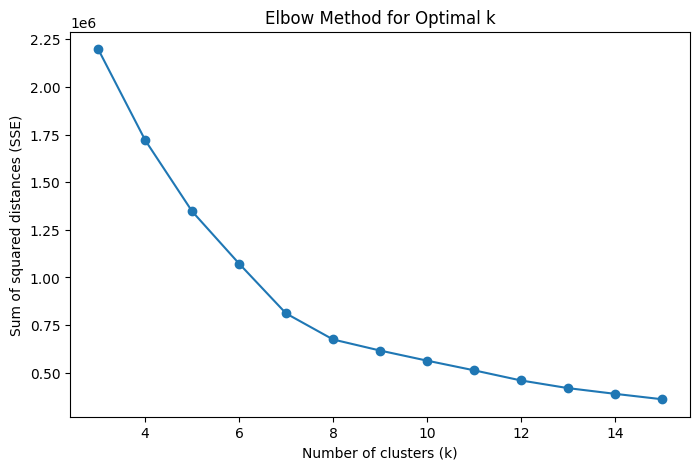

Optimal number of clusters: 3


In [209]:
kmeans_elbow_method(Sp)

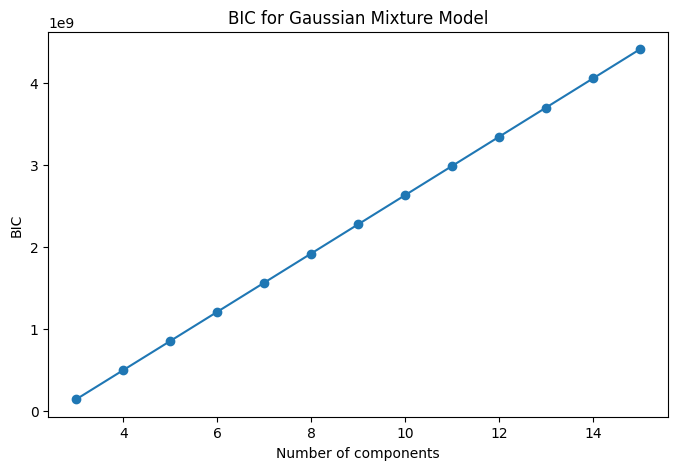

Optimal number of clusters: 3


In [208]:
gmm_bic_method(Sp)

# Bootstrap analysis of stable clusters

In [246]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from collections import Counter

# Parameters Setting for Clustering 
min_k, max_k = 3, 15  # Range of Clusters
num_iterations = 10000  # Number of Iterations
random_k = np.zeros((num_iterations), dtype=int)
cluster_labels = np.zeros((num_iterations, Qmri_reordered[mask_new].shape[0]), dtype=int)

# Randomly select the number of clusters at each iteration and perform KMean
for i in range(num_iterations):
    random_k[i] = np.random.randint(min_k, max_k + 1)  # Random K between 3 and 15
    kmeans = KMeans(n_clusters=random_k[i], random_state=None, n_init=10, init='random')
    labels = kmeans.fit_predict(Qmri_reordered[mask_new])  # Results
    cluster_labels[i, :] = labels  # Save

    # Print each iteration
    print(f"Iteration: {i} of {num_iterations}", end="\r")

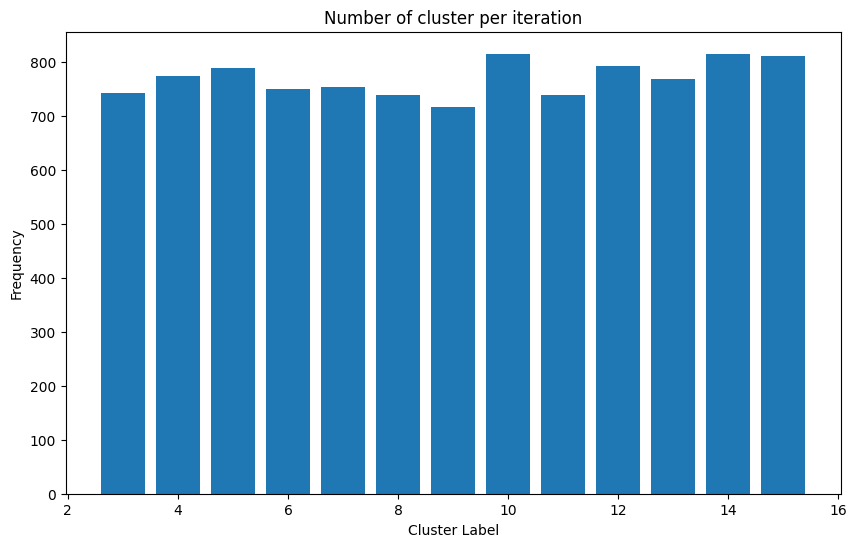

In [247]:
# Visualization (Number of cluster per iteration)
plt.figure(figsize=(10, 6))
plt.hist(random_k, bins=range(min_k, max_k + 2), align='left', rwidth=0.8)
plt.xlabel("Cluster Label")
plt.ylabel("Frequency")
plt.title("Number of cluster per iteration")
plt.show()

# Find optimal k (ex: most common selected k)
optimal_k = Counter(label_counts).most_common(1)[0][0]

# Pairwise stability of a stochastic clustering process
the probability that a given pair of regions i and j belong to the same cluster:
$$S_{ij}=Pr(\Phi_{ij}(y)=1 | Y \rightarrow^f y)$$

In [183]:
def create_binary_matrix(vector):
    # Convert the vector to a numpy array
    vector = np.array(vector)
    # Create a matrix where each element (i, j) is 1 if vector[i] == vector[j], else 0
    Sb = (vector[:, None] == vector).astype(int)
    return Sb

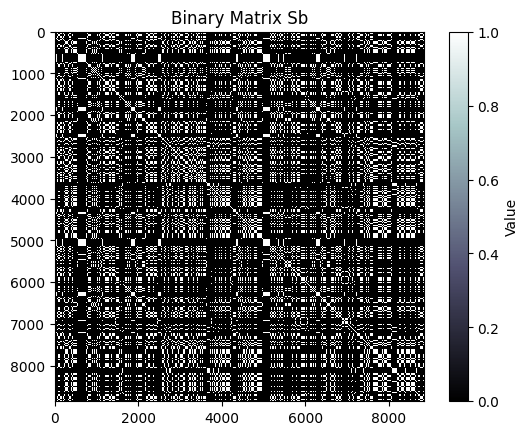

In [197]:
# Get an example of the binarized matrix
Sb = create_binary_matrix(cluster_labels[9,:])

# Plot the binary matrix with the 'bone' colormap
plt.imshow(Sb, cmap='bone', interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Binary Matrix Sb')
plt.show()

In [248]:
# Create matrix of zeros
Sp = np.zeros((cluster_labels.shape[1],cluster_labels.shape[1]))

# Calculate the probability matrix
for i in range(num_iterations):
    Sp = Sp + create_binary_matrix(cluster_labels[i,:])

    # Print each iteration
    print(f"Iteration: {i} of {num_iterations}", end="\r")

# Divide the sum by the number of iterations
Sp = Sp / num_iterations

print('Done!!')

Done!!ion: 9999 of 10000


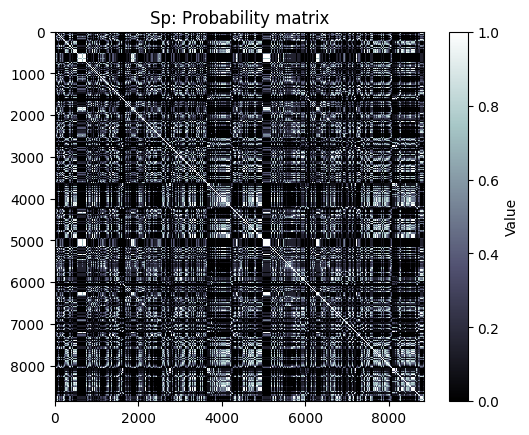

In [249]:
# Plot the binary matrix with the 'bone' colormap
plt.imshow(Sp, cmap='bone', interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Sp: Probability matrix')
plt.show()

In [320]:
np.save('/home/bic/yhwang/Desktop/Sp.npy', Sp)

## Sb sorted visualization

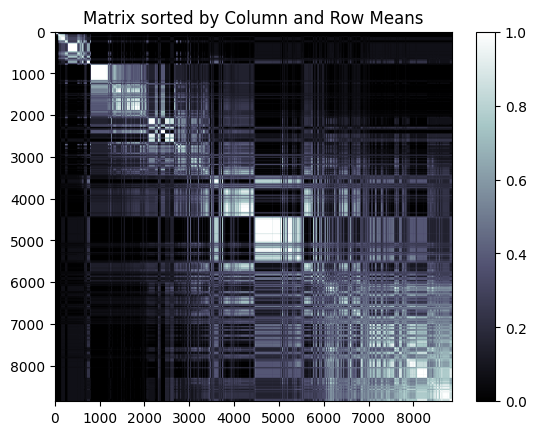

In [286]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Sort columns by their mean values
column_means = np.mean(Sp, axis=0)
sorted_col_indices = np.argsort(column_means)
sorted_matrix = Sp[:, sorted_col_indices]

# Sort rows by their mean values in the sorted matrix
row_means = np.mean(sorted_matrix, axis=1)
sorted_row_indices = np.argsort(row_means)
sorted_matrix = sorted_matrix[sorted_row_indices]

# Plot the sorted matrix
plt.imshow(sorted_matrix, cmap='bone', aspect='auto')
plt.colorbar()
plt.title('Matrix sorted by Column and Row Means')
plt.show()

# Hierarchical agglomerative clustering (HAC)

In [292]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram, ward
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import pdist, squareform

def hierarchical_clustering(Sb, max_clusters=15):
    # Compute the pairwise distances using Euclidean distance
    distances = pdist(Sb, metric='euclidean')

    # Convert the condensed distance matrix to a square form
    distance_matrix = squareform(distances)

    # Perform Hierarchical Agglomerative Clustering using linkage
    # 'average' linkage often works well with binary similarity matrices
    Z = ward(distance_matrix)

    return Z

In [293]:
HAC = hierarchical_clustering(Sp)

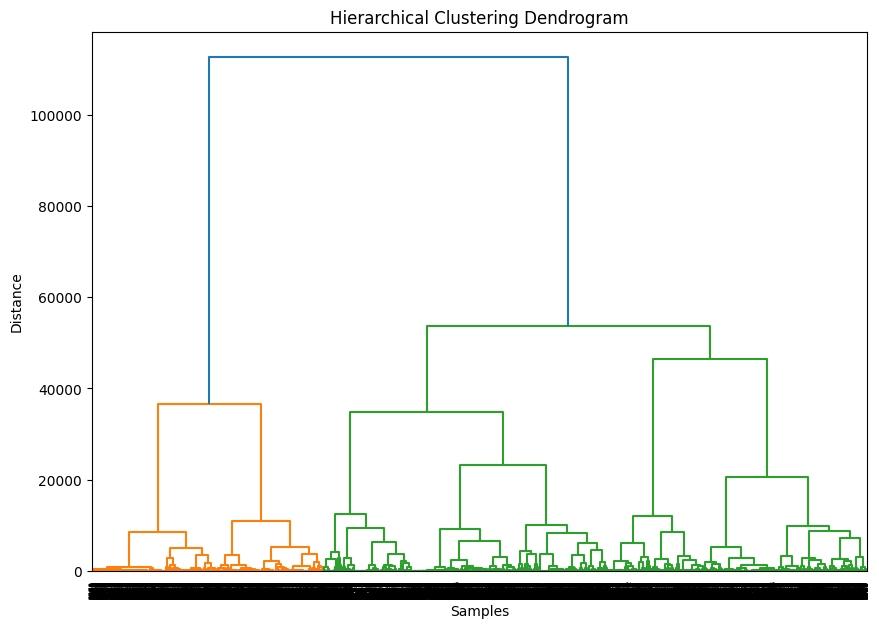

In [294]:
# Plot the dendrogram to visualize and select optimal clusters
plt.figure(figsize=(10, 7))
dendrogram(HAC)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [336]:
num_k = 16
# Using a threshold to determine the optimal number of clusters
# You could use a distance criterion or select a fixed number
cluster_assignments = fcluster(HAC, t=num_k, criterion='maxclust')

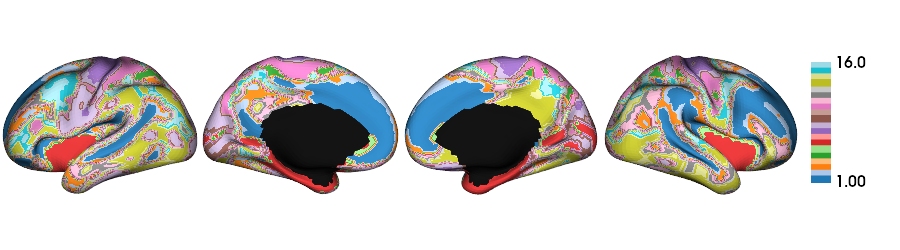

In [337]:
# Labels to surface
labels_5k = masked_to_5k(cluster_assignments, mask_new)

# Plot surface
plot_hemispheres(inf_lh, inf_rh, array_name=labels_5k, cmap='tab20', nan_color=(0, 0, 0, 1),
  zoom=1.25, size=(900, 250), embed_nb=True, color_range=(1, num_k),
  color_bar='right', screenshot=False)

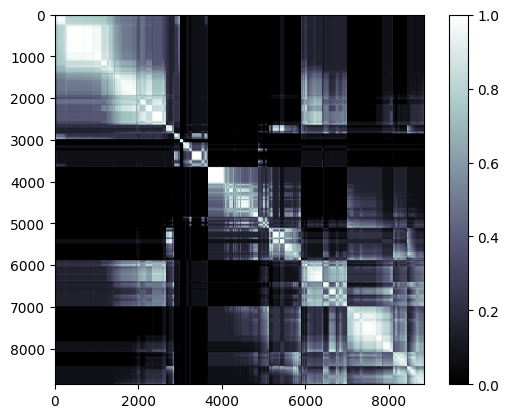

In [338]:
# Step 1: Sort the cluster_assignments and get the sorted indices
sorted_indices = np.argsort(cluster_assignments)
sorted_cluster_assignments = cluster_assignments[sorted_indices]

# Step 2: Sort the rows and columns of the matrix Sp
sorted_Sp = Sp[sorted_indices, :][:, sorted_indices]

# Step 3: Within each label group, sort the rows by their mean values
unique_labels = np.unique(sorted_cluster_assignments)
sorted_rows = []

for label in unique_labels:
    label_indices = np.where(sorted_cluster_assignments == label)[0]
    label_rows = sorted_Sp[label_indices, :]
    row_means = label_rows.mean(axis=1)
    sorted_label_indices = label_indices[np.argsort(row_means)]
    sorted_rows.extend(sorted_label_indices)

# Step 4: Sort the matrix by the new sorted rows
final_sorted_Sp = sorted_Sp[sorted_rows, :][:, sorted_rows]

# Step 5: Plot the sorted matrix using the bone colormap
plt.imshow(final_sorted_Sp, cmap='bone')
plt.colorbar()
plt.show()

## HAC with average methods and silhouette

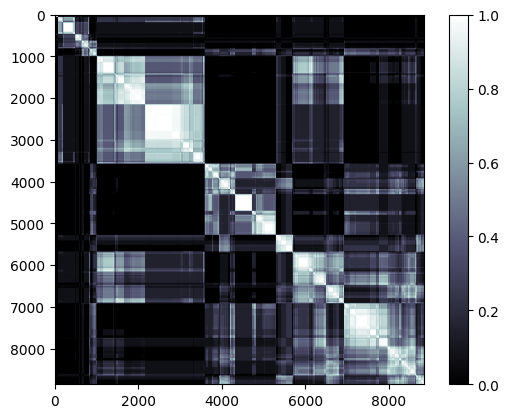

In [329]:
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform

# Step 1: Convert the similarity matrix to a distance matrix
distance_matrix = 1 - Sp

# Step 2: Convert the square distance matrix to a condensed distance matrix
condensed_distance_matrix = squareform(distance_matrix)

# Step 3: Perform hierarchical clustering using the linkage method
Z = linkage(condensed_distance_matrix, method='average')

# Step 4: Get the order of the leaves (indices) from the dendrogram
dendro = dendrogram(Z, no_plot=True)
ordered_indices = leaves_list(Z)

# Step 5: Reorder the matrix based on the clustering results
ordered_Sp = Sp[ordered_indices, :][:, ordered_indices]

# Step 6: Plot the reordered matrix using the bone colormap
plt.imshow(ordered_Sp, cmap='bone')
plt.colorbar()
plt.show()

In [333]:
# Determine the optimal number of clusters using the silhouette score
max_clusters = 18
silhouette_scores = []

for num_clusters in range(2, max_clusters + 1):
    labels = fcluster(Z, num_clusters, criterion='maxclust')
    score = silhouette_score(distance_matrix, labels, metric='precomputed')
    silhouette_scores.append(score)

optimal_num_clusters = np.argmax(silhouette_scores) + 2  # +2 because range starts from 2

print("Optimal number of clusters:", optimal_num_clusters)

Optimal number of clusters: 16


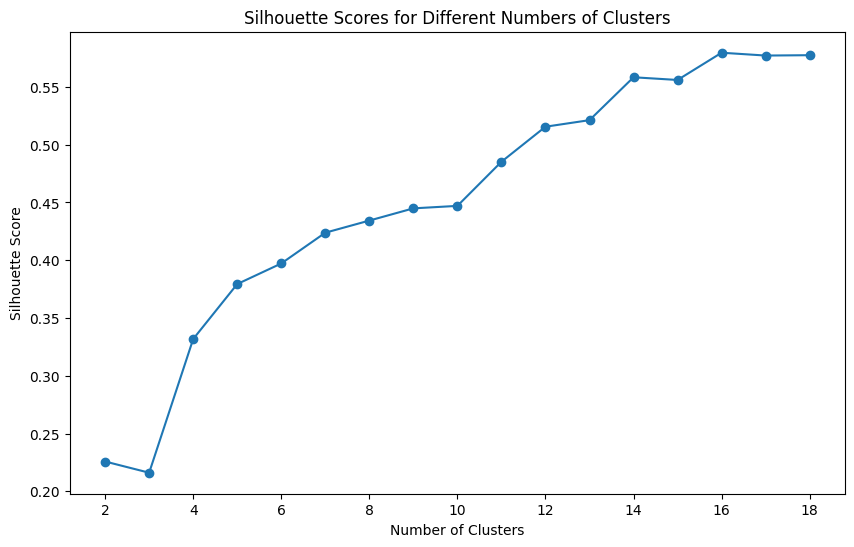

In [334]:
# Plot the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

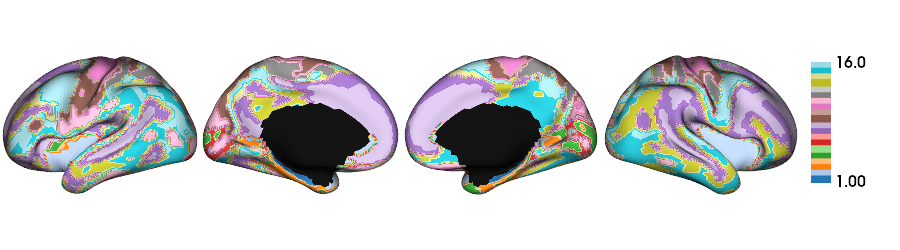

In [335]:
# Extract flat clusters (labels) using the optimal number of clusters
labels = fcluster(Z, optimal_num_clusters, criterion='maxclust')

# Labels to surface
labels_5k = masked_to_5k(labels, mask_new)

# Plot surface
plot_hemispheres(inf_lh, inf_rh, array_name=labels_5k, cmap='tab20', nan_color=(0, 0, 0, 1),
  zoom=1.25, size=(900, 250), embed_nb=True, color_range=(1, optimal_num_clusters),
  color_bar='right', screenshot=False)

# This is optional to QC the pSM!!!

> **Note:** Clean the mask and remove those vertices with high covariance. and re-run all the process

In [252]:
# Get the index of the non medial wall regions
indx_mask = np.where(mask_new==1)[0]

# Number of gradients
Ngrad = 5

# Calculate the gradients
PSM = GradientMaps(n_components=Ngrad, random_state=None, approach='dm', kernel=None)
PSM.fit(Sp, sparsity=0)
    
# Map gradients to surface
grad = [None] * Ngrad
for i, g in enumerate(PSM.gradients_.T[0:Ngrad,:]):
    # create a new array filled with NaN values
    g_nan = np.full(mask_new.shape, np.nan)
    g_nan[indx_mask] = g

    # fill in the calculated values into the corresponding indices of the new array
    grad[i] = g_nan

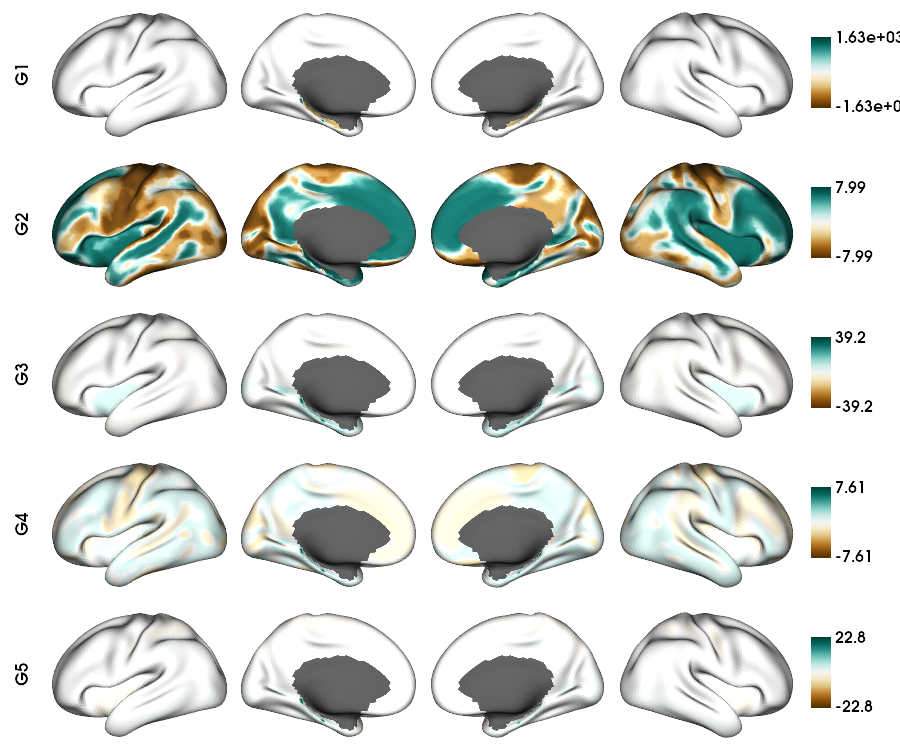

In [253]:
# plot the gradients
labels=['G'+str(x) for x in list(range(1,Ngrad+1))]
plot_hemispheres(inf_lh, inf_rh, array_name=grad, cmap='BrBG', nan_color=(0.3, 0.3, 0.3, 1),
  zoom=1.5, size=(900, 150*Ngrad), embed_nb=True, color_range = 'sym',
  color_bar='right', label_text={'left': labels}, screenshot=False)

## Create a new mask

In [230]:
bin_grad = np.where(grad[0] >= 50, 1, 0)

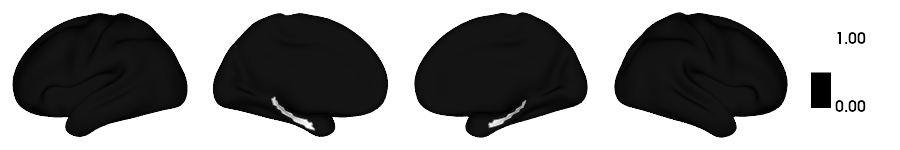

In [233]:
plot_hemispheres(inf_lh, inf_rh, array_name=bin_grad, cmap='binary_r', nan_color=(0.3, 0.3, 0.3, 1),
  zoom=1.5, size=(900, 150), embed_nb=True, color_bar='right', screenshot=False)

In [243]:
mask_new = np.logical_or(mask_5k, bin_grad.astype(bool))

In [245]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/mask_new.npy', mask_new)

In [244]:
mask_new

array([ True,  True,  True, ...,  True,  True,  True])

# Calculate the optimal number of clusters on Sp

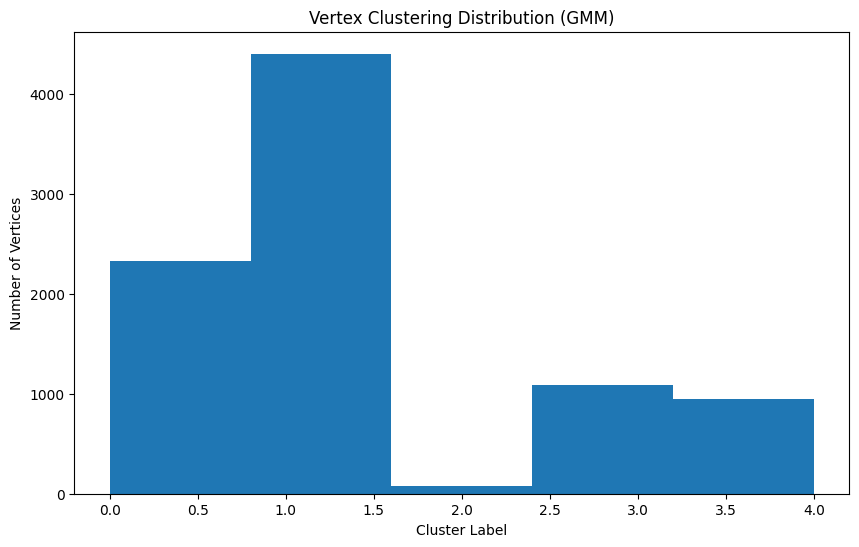

In [262]:
optimal_k = 8
gmm = GaussianMixture(n_components=optimal_k, random_state=None, n_init=10)
labels = gmm.fit_predict(Qmri_reordered[mask_new])

plt.figure(figsize=(10,6))
plt.hist(labels, bins=optimal_k)
plt.xlabel("Cluster Label")
plt.ylabel("Number of Vertices")
plt.title("Vertex Clustering Distribution (GMM)")
plt.show()

In [256]:
def masked_to_5k(vec, mask_new, midwall_value=np.nan):
    # Get the index of the non medial wall regions
    indx = np.where(mask_new==1)[0]
    
    # create a new array filled with NaN values
    g_nan = np.full(mask_new.shape, midwall_value)
    g_nan[indx] = vec
    return(g_nan)

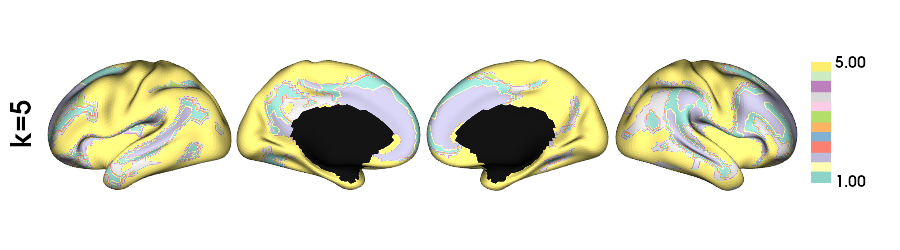

In [264]:
# Labels to surface
labels_5k = masked_to_5k(clusters, mask_new)

# Plot surface
plot_hemispheres(inf_lh, inf_rh, array_name=labels_5k, cmap='Set3', nan_color=(0, 0, 0, 1),
  zoom=1.25, size=(900, 250), embed_nb=True, color_range=(1, optimal_k),
  color_bar='right', label_text={'left': [f'k={optimal_k}']}, screenshot=False)

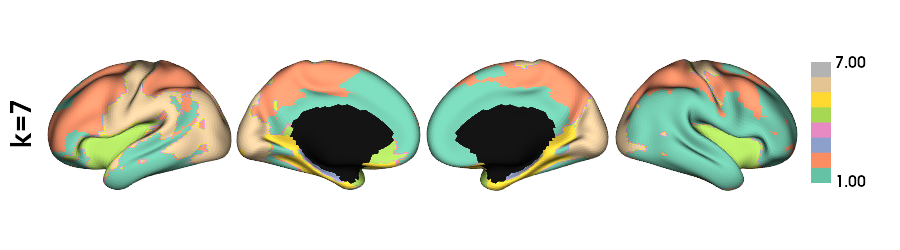

In [162]:
# Labels to surface
labels_5k = masked_to_5k(labels, mask_5k)

# Plot surface
plot_hemispheres(inf_lh, inf_rh, array_name=labels_5k, cmap='Set2', nan_color=(0, 0, 0, 1),
  zoom=1.25, size=(900, 250), embed_nb=True, color_range=(1, optimal_k),
  color_bar='right', label_text={'left': [f'k={optimal_k}']}, screenshot=False)


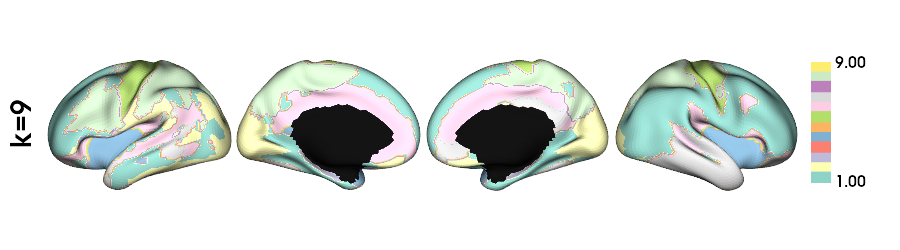

In [154]:
# Labels to surface
labels_5k = masked_to_5k(labels, mask_5k)

# Plot surface
plot_hemispheres(inf_lh, inf_rh, array_name=labels_5k, cmap='Set3', nan_color=(0, 0, 0, 1),
  zoom=1.25, size=(900, 250), embed_nb=True, color_range=(1, optimal_k),
  color_bar='right', label_text={'left': [f'k={optimal_k}']}, screenshot=False)
